<a href="https://colab.research.google.com/github/RaymCharles/Projet-CNN/blob/main/Projet_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet Machine Learning

## 1. Compréhension et préparation des données

### Task 1 - Chargement du dataset CIFAR-10

In [49]:
import tensorflow as tf

print("TensorFlow :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [50]:
# Bibliothèques de base
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow et Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Vérification de la version TensorFlow
print("Version TensorFlow :", tf.__version__)

Version TensorFlow : 2.20.0


In [51]:
# Chargement du dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [52]:
# Affichage des dimensions du dataset

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de y_train :", y_train.shape)

print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (50000, 32, 32, 3)
Dimensions de y_train : (50000, 1)
Dimensions de X_test : (10000, 32, 32, 3)
Dimensions de y_test : (10000, 1)


#### Réponses aux questions

- Nombre d'images d'entraînement : 50 000
- Nombre d'images de test : 10 000

- Chaque image possède une dimension de 32 × 32 pixels.
- Les images possèdent 3 canaux de couleur (RGB : Red, Green, Blue).

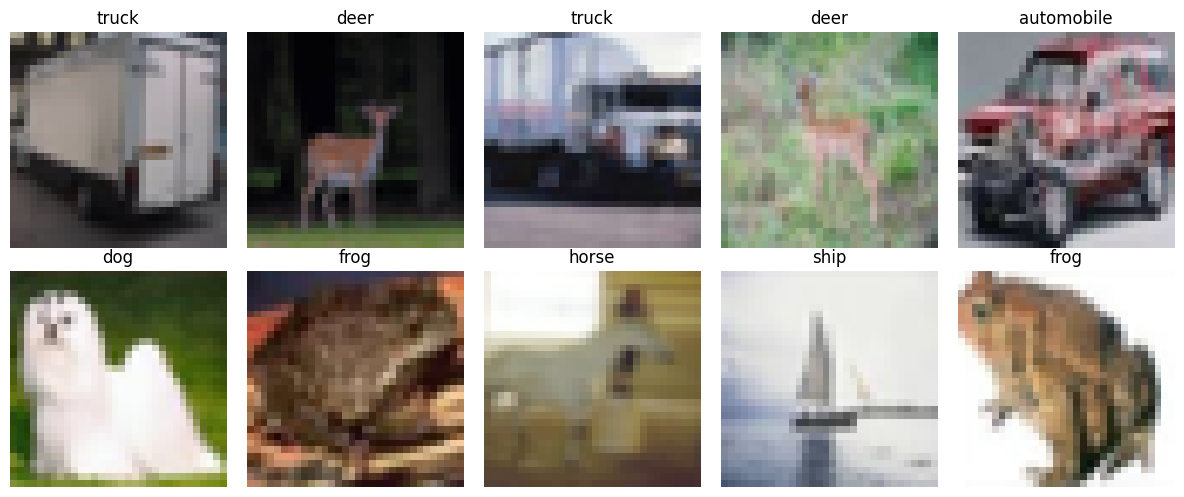

In [53]:
# Noms des classes CIFAR-10

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Affichage de 10 images aléatoires

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    index = np.random.randint(0, len(X_train))

    plt.imshow(X_train[index])

    plt.title(class_names[y_train[index][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Analyse des images

Les images du dataset CIFAR-10 représentent différentes catégories d’objets telles que des avions, des voitures, des oiseaux, des chats ou encore des bateaux.

Les labels sont des données catégorielles. Ils sont initialement représentés par des valeurs numériques comprises entre 0 et 9, chaque valeur correspondant à une classe spécifique.

Les images sont relativement petites (32 × 32 pixels), ce qui rend certaines classes difficiles à distinguer. Pour un humain, certaines images sont facilement reconnaissables, tandis que d’autres peuvent être ambiguës en raison de leur faible résolution.

In [54]:
# Affichage de quelques labels

print("Premiers labels du dataset :")
print(y_train[:10].flatten())

Premiers labels du dataset :
[6 9 9 4 1 1 2 7 8 3]


#### Nature des labels

Les labels sont stockés sous forme de nombres entiers compris entre 0 et 9.

Cependant, ces valeurs numériques ne représentent pas des quantités mais des catégories d’objets (avion, voiture, chat, chien, etc.).

Les labels sont donc des données catégorielles encodées numériquement.

In [55]:
# Vérification des valeurs des pixels avant normalisation

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0
Valeur maximale : 255


In [56]:
# Normalisation des images

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [57]:
# Vérification après normalisation

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0.0
Valeur maximale : 1.0


#### Pourquoi normaliser les données ?

La normalisation consiste à ramener les valeurs des pixels de l’intervalle [0,255] vers l’intervalle [0,1].

Cette étape est importante car elle permet d’éviter que certaines caractéristiques aient des valeurs beaucoup plus grandes que d’autres. Elle facilite également le calcul du gradient lors de l’apprentissage.

#### Impact de la normalisation sur les réseaux de neurones

La normalisation améliore la stabilité numérique du modèle et accélère la convergence pendant l’entraînement.

Elle permet généralement d’obtenir un apprentissage plus rapide, plus stable et de meilleures performances de classification.

In [58]:
# Forme des labels avant one-hot encoding

print("y_train shape avant encodage :", y_train.shape)
print("Exemple de label avant encodage :", y_train[0])

y_train shape avant encodage : (50000, 1)
Exemple de label avant encodage : [6]


In [59]:
# One-hot encoding des labels

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [60]:
# Vérification après one-hot encoding

print("y_train_cat shape après encodage :", y_train_cat.shape)
print("Exemple de label après encodage :", y_train_cat[0])

y_train_cat shape après encodage : (50000, 10)
Exemple de label après encodage : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


#### One-Hot Encoding des labels

Le one-hot encoding transforme chaque label numérique en un vecteur binaire de taille égale au nombre de classes.

Dans CIFAR-10, il y a 10 classes. Un label comme `3` est donc transformé en un vecteur contenant dix valeurs, avec un `1` à la position correspondant à la classe et des `0` ailleurs.

Cette transformation est nécessaire pour un problème de classification multi-classes lorsque l’on utilise une couche de sortie avec 10 neurones et une fonction d’activation softmax.

Elle permet au réseau de comparer ses prédictions, qui sont des probabilités pour chaque classe, avec la vraie classe représentée sous forme de vecteur.

In [61]:
# Comptage du nombre d'images par classe

unique, counts = np.unique(y_train, return_counts=True)

for classe, nombre in zip(unique, counts):
    print(f"{class_names[classe]} : {nombre}")

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


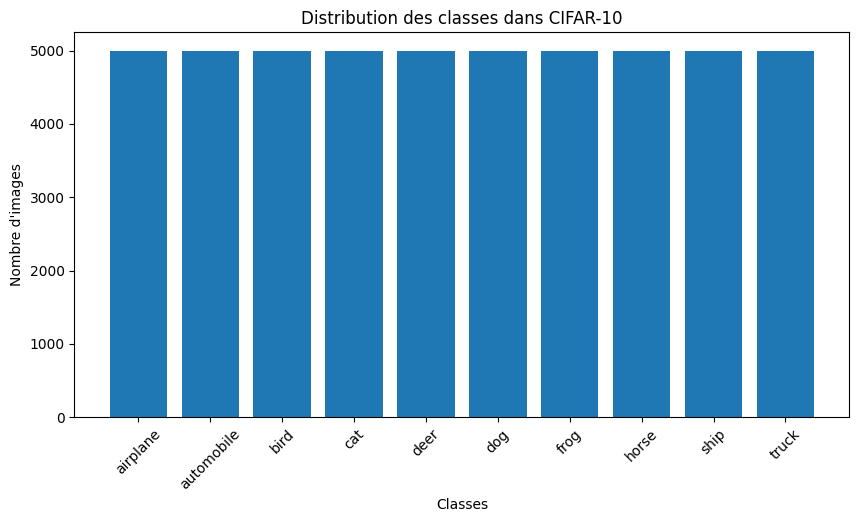

In [62]:
# Distribution des classes

plt.figure(figsize=(10, 5))

plt.bar(class_names, counts)

plt.title("Distribution des classes dans CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.xticks(rotation=45)

plt.show()

#### Analyse de la distribution des classes

Le graphique montre que chaque classe contient 5000 images dans l’ensemble d’entraînement.

Le dataset CIFAR-10 est donc équilibré puisque toutes les classes sont représentées par le même nombre d’exemples.

L’analyse de la distribution des classes est importante avant l’entraînement d’un modèle car un déséquilibre pourrait entraîner un biais du modèle vers les classes majoritaires. Dans le cas de CIFAR-10, ce problème n’existe pas puisque les classes sont uniformément réparties.

## 2. Modélisation des données

### Modèle 1 - LeNet5

In [63]:
# Importation des outils nécessaires pour construire les CNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam

In [64]:
# Définition du modèle LeNet5

def build_lenet5():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    model.add(Conv2D(6, kernel_size=(5, 5), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(16, kernel_size=(5, 5), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(120, activation="relu"))
    model.add(Dense(84, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [65]:
# Création et affichage du résumé du modèle LeNet5

lenet5_model = build_lenet5()
lenet5_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Compilation du modèle LeNet5 avec SGD

lenet5_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
# Entraînement du modèle

history_lenet5_sgd = lenet5_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1130 - loss: 2.2962 - val_accuracy: 0.1287 - val_loss: 2.2895
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1464 - loss: 2.2833 - val_accuracy: 0.1567 - val_loss: 2.2754
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1671 - loss: 2.2651 - val_accuracy: 0.1818 - val_loss: 2.2519
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1910 - loss: 2.2332 - val_accuracy: 0.1970 - val_loss: 2.2107
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2144 - loss: 2.1851 - val_accuracy: 0.2246 - val_loss: 2.1599
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2318 - loss: 2.1377 - val_accuracy: 0.2361 - val_loss: 2.1218
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2502 - loss: 2.0978 - val_accuracy: 0.2535 - val_loss: 2.0830
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2671 - loss: 2.0589 - val_accuracy: 0.

In [68]:
# Fonction d'affichage des courbes d'apprentissage

def plot_history(history):

    # Courbe de loss
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title('Evolution de la fonction de perte')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Courbe d'accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Evolution de l'accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

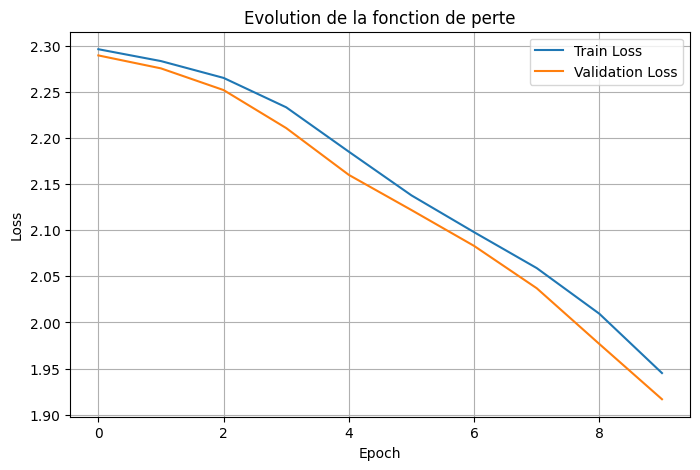

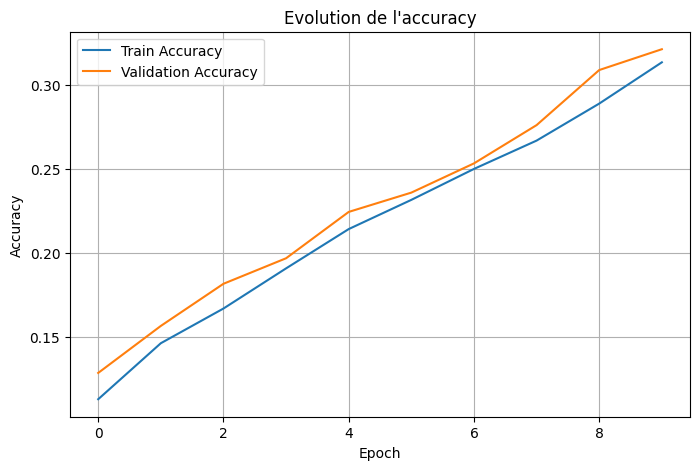

In [69]:
# Affichage des courbes pour LeNet5 + SGD

plot_history(history_lenet5_sgd)

In [70]:
# Evaluation finale du modèle LeNet5 avec SGD

train_loss = history_lenet5_sgd.history["loss"][-1]
train_acc = history_lenet5_sgd.history["accuracy"][-1]

val_loss = history_lenet5_sgd.history["val_loss"][-1]
val_acc = history_lenet5_sgd.history["val_accuracy"][-1]

print("LeNet5 + SGD")
print("Train Loss :", train_loss)
print("Train Accuracy :", train_acc)
print("Validation Loss :", val_loss)
print("Validation Accuracy :", val_acc)

LeNet5 + SGD
Train Loss : 1.9451165199279785
Train Accuracy : 0.31369999051094055
Validation Loss : 1.916757583618164
Validation Accuracy : 0.3215000033378601


In [71]:
# Stockage des résultats dans une liste

results = []

results.append({
    "Model": "LeNet5",
    "Optimizer": "SGD",
    "Learning Rate": 0.001,
    "Epochs": 10,
    "Train Loss": train_loss,
    "Train Accuracy": train_acc,
    "Validation Loss": val_loss,
    "Validation Accuracy": val_acc
})

In [72]:
# Affichage des résultats sous forme de tableau

import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,10,1.945117,0.3137,1.916758,0.3215


### Modèle 2 - VGG1

In [73]:
# Définition du modèle VGG1

def build_vgg1():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    # Bloc VGG 1
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classification
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [74]:
# Création et affichage du résumé du modèle VGG1

vgg1_model = build_vgg1()
vgg1_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Compilation du modèle VGG1 avec SGD

vgg1_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [76]:
# Entraînement du modèle VGG1

history_vgg1_sgd = vgg1_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1585 - loss: 2.2678 - val_accuracy: 0.1952 - val_loss: 2.2288
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2264 - loss: 2.1657 - val_accuracy: 0.2466 - val_loss: 2.1046
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2827 - loss: 2.0395 - val_accuracy: 0.2960 - val_loss: 1.9813
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3195 - loss: 1.9356 - val_accuracy: 0.3329 - val_loss: 1.8991
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3427 - loss: 1.8766 - val_accuracy: 0.3346 - val_loss: 1.8714
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3566 - loss: 1.8365 - val_accuracy: 0.3450 - val_loss: 1.8354
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3681 - loss: 1.8012 - val_accuracy: 0.3453 - val_loss: 1.8284
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3817 - loss: 1.7697 - val_accuracy: 0.

### Modèle 3 - VGG2

In [77]:
# Définition du modèle VGG2

def build_vgg2():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    # Bloc VGG 1
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Bloc VGG 2
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Classification
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [78]:
# Création et affichage du résumé du modèle VGG2

vgg2_model = build_vgg2()
vgg2_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,202 (1.11 MB)

 Trainable params: 292,202 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

### Modèle 4 - VGG3

In [79]:
# Définition du modèle VGG3

def build_vgg3():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    for i in range(3):
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

In [80]:
# Création et affichage du résumé du modèle VGG3

vgg3_model = build_vgg3()
vgg3_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,090 (445.66 KB)

 Trainable params: 114,090 (445.66 KB)

 Non-trainable params: 0 (0.00 B)

### Modèle 5 - VGG3 avec Dropout

In [81]:
# Importation de la couche Dropout

from tensorflow.keras.layers import Dropout

In [82]:
# Définition du modèle VGG3 avec Dropout

def build_vgg3_dropout():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    for i in range(3):
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation="softmax"))

    return model

In [83]:
# Création et affichage du résumé du modèle VGG3 avec Dropout

vgg3_dropout_model = build_vgg3_dropout()
vgg3_dropout_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,090 (445.66 KB)

 Trainable params: 114,090 (445.66 KB)

 Non-trainable params: 0 (0.00 B)

### Modèle 6 - VGG3 avec Dropout et Batch Normalization

In [84]:
# Importation de BatchNormalization

from tensorflow.keras.layers import BatchNormalization

In [85]:
# Définition du modèle VGG3 avec Dropout et Batch Normalization

def build_vgg3_dropout_bn():
    model = Sequential()

    model.add(tf.keras.Input(shape=(32, 32, 3)))

    for i in range(3):

        model.add(Conv2D(32, kernel_size=(3, 3), padding="same"))
        model.add(BatchNormalization())
        model.add(tf.keras.layers.Activation("relu"))

        model.add(Conv2D(32, kernel_size=(3, 3), padding="same"))
        model.add(BatchNormalization())
        model.add(tf.keras.layers.Activation("relu"))

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(tf.keras.layers.Activation("relu"))

    model.add(Dropout(0.5))

    model.add(Dense(10, activation="softmax"))

    return model

In [86]:
# Création et affichage du résumé du modèle

vgg3_dropout_bn_model = build_vgg3_dropout_bn()
vgg3_dropout_bn_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 512)            │             

 Total params: 115,370 (450.66 KB)

 Trainable params: 114,730 (448.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [87]:
# Fonction générique d'entraînement d'un modèle

def train_model(model_builder, model_name, optimizer_name, learning_rate, epochs=50, batch_size=64):

    # Création d'un nouveau modèle à chaque entraînement
    model = model_builder()

    # Choix de l'optimiseur
    if optimizer_name == "SGD":
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Optimizer not supported")

    # Compilation du modèle
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Entraînement du modèle
    history = model.fit(
        X_train,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test_cat),
        verbose=1
    )

    # Récupération des résultats finaux
    result = {
        "Model": model_name,
        "Optimizer": optimizer_name,
        "Learning Rate": learning_rate,
        "Epochs": epochs,
        "Train Loss": history.history["loss"][-1],
        "Train Accuracy": history.history["accuracy"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1]
    }

    return model, history, result

In [88]:
# Liste des modèles à comparer

model_builders = {
    "LeNet5": build_lenet5,
    "VGG1": build_vgg1,
    "VGG2": build_vgg2,
    "VGG3": build_vgg3,
    "VGG3 + Dropout": build_vgg3_dropout,
    "VGG3 + Dropout + BatchNorm": build_vgg3_dropout_bn
}

# Optimiseurs à tester
optimizers = ["SGD", "Adam"]

# Learning rates indiqués dans le sujet
learning_rates = [0.001, 0.01, 0.1]

# Nombre d'epochs indiqué dans le sujet
epochs = 50

In [89]:
# Expérience officielle 1 : LeNet5 + SGD + LR = 0.001

official_results = []

model_lenet5_sgd_001, history_lenet5_sgd_001, result_lenet5_sgd_001 = train_model(
    model_builder=build_lenet5,
    model_name="LeNet5",
    optimizer_name="SGD",
    learning_rate=0.001,
    epochs=50,
    batch_size=64
)

official_results.append(result_lenet5_sgd_001)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1243 - loss: 2.2971 - val_accuracy: 0.1225 - val_loss: 2.2897
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1292 - loss: 2.2806 - val_accuracy: 0.1436 - val_loss: 2.2713
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1578 - loss: 2.2538 - val_accuracy: 0.1726 - val_loss: 2.2322
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1912 - loss: 2.1975 - val_accuracy: 0.2057 - val_loss: 2.1572
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2262 - loss: 2.1080 - val_accuracy: 0.2369 - val_loss: 2.0592
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2649 - loss: 2.0222 - val_accuracy: 0.2822 - val_loss: 1.9925
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2933 - loss: 1.9677 - val_accuracy: 0.3059 - val_loss: 1.9464
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3092 - loss: 1.9321 - val_accuracy: 0.

In [90]:
official_results_df = pd.DataFrame(official_results)
official_results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.39328,0.4975


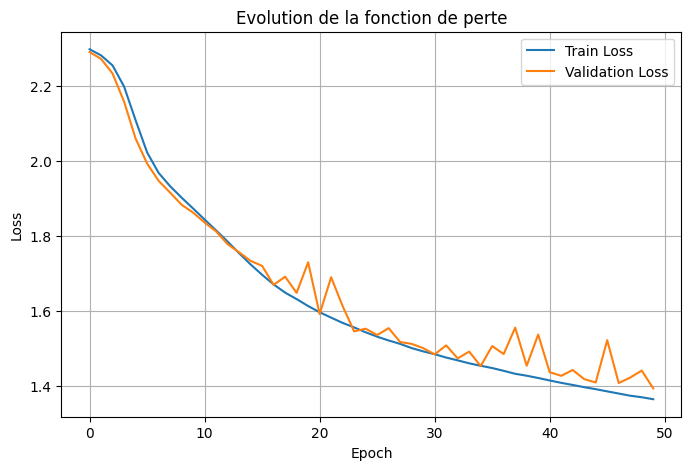

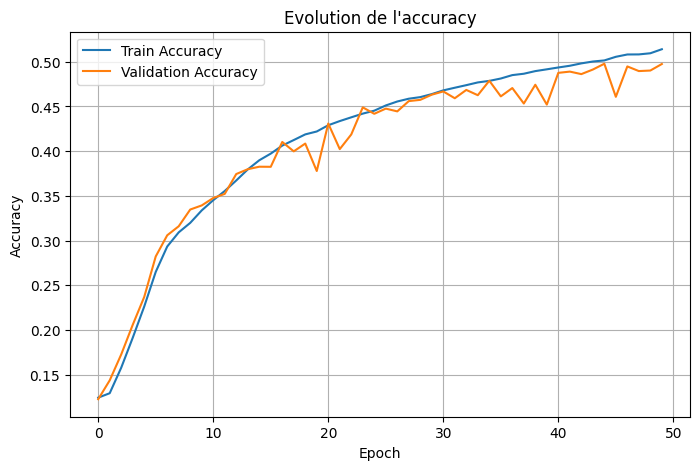

In [91]:
plot_history(history_lenet5_sgd_001)

#### Analyse des courbes d'apprentissage

La fonction de perte diminue progressivement sur les ensembles d'entraînement et de validation, ce qui montre que le modèle apprend correctement au cours des époques.

Les deux courbes restent proches pendant l'entraînement, ce qui indique une bonne capacité de généralisation et l'absence d'overfitting significatif.

On observe une augmentation ponctuelle de la perte de validation autour de l'époque 28. Cependant, cette fluctuation disparaît rapidement et n'affecte pas la tendance globale du modèle.

In [92]:
# Expériences officielles pour LeNet5 uniquement

for optimizer_name in optimizers:
    for lr in learning_rates:

        # Eviter de refaire l'expérience déjà réalisée
        if optimizer_name == "SGD" and lr == 0.001:
            continue

        print("=" * 60)
        print(f"Entraînement : LeNet5 | Optimizer = {optimizer_name} | LR = {lr}")
        print("=" * 60)

        model, history, result = train_model(
            model_builder=build_lenet5,
            model_name="LeNet5",
            optimizer_name=optimizer_name,
            learning_rate=lr,
            epochs=50,
            batch_size=64
        )

        official_results.append(result)

Entraînement : LeNet5 | Optimizer = SGD | LR = 0.01
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2281 - loss: 2.1011 - val_accuracy: 0.2146 - val_loss: 2.2495
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3516 - loss: 1.8215 - val_accuracy: 0.3769 - val_loss: 1.7319
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4057 - loss: 1.6685 - val_accuracy: 0.4060 - val_loss: 1.6436
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4399 - loss: 1.5676 - val_accuracy: 0.4384 - val_loss: 1.5665
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4625 - loss: 1.5047 - val_accuracy: 0.4564 - val_loss: 1.5229
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4773 - loss: 1.4622 - val_accuracy: 0.4588 - val_loss: 1.5041
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4907 - loss: 1.4269 - val_accuracy: 0.4775 - val_loss: 1.4938
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step 

In [93]:
official_results_df = pd.DataFrame(official_results)
official_results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000


In [94]:
# Expériences officielles pour VGG1 uniquement

for optimizer_name in optimizers:
    for lr in learning_rates:

        print("=" * 60)
        print(f"Entraînement : VGG1 | Optimizer = {optimizer_name} | LR = {lr}")
        print("=" * 60)

        model, history, result = train_model(
            model_builder=build_vgg1,
            model_name="VGG1",
            optimizer_name=optimizer_name,
            learning_rate=lr,
            epochs=50,
            batch_size=64
        )

        official_results.append(result)

Entraînement : VGG1 | Optimizer = SGD | LR = 0.001
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1485 - loss: 2.2753 - val_accuracy: 0.1798 - val_loss: 2.2398
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2311 - loss: 2.1707 - val_accuracy: 0.2650 - val_loss: 2.0990
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2902 - loss: 2.0260 - val_accuracy: 0.3128 - val_loss: 1.9655
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3310 - loss: 1.9220 - val_accuracy: 0.3167 - val_loss: 1.9100
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3515 - loss: 1.8671 - val_accuracy: 0.3306 - val_loss: 1.8768
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3666 - loss: 1.8248 - val_accuracy: 0.3572 - val_loss: 1.8177
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3796 - loss: 1.7856 - val_accuracy: 0.3864 - val_loss: 1.7643
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step -

In [95]:
official_results_df = pd.DataFrame(official_results)
official_results_df

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000
6,VGG1,SGD,0.001,50,1.118848,0.60900,1.339775,0.5243
7,VGG1,SGD,0.010,50,0.007663,0.99980,2.345185,0.6508
8,VGG1,SGD,0.100,50,0.000048,1.00000,3.462363,0.6809
9,VGG1,Adam,0.001,50,0.031579,0.98974,4.524968,0.6392


In [96]:
# Sauvegarde des résultats actuels dans un fichier CSV

official_results_df = pd.DataFrame(official_results)
official_results_df.to_csv("official_results.csv", index=False)

print("Résultats sauvegardés dans official_results.csv")

Résultats sauvegardés dans official_results.csv


In [97]:
# Fonction pour sauvegarder les résultats après chaque expérience

def save_results(results, filename="official_results.csv"):
    results_df = pd.DataFrame(results)
    results_df.to_csv(filename, index=False)
    return results_df

In [98]:
# Expériences officielles restantes

remaining_model_builders = {
    "VGG2": build_vgg2,
    "VGG3": build_vgg3,
    "VGG3 + Dropout": build_vgg3_dropout,
    "VGG3 + Dropout + BatchNorm": build_vgg3_dropout_bn
}

for model_name, model_builder in remaining_model_builders.items():
    for optimizer_name in optimizers:
        for lr in learning_rates:

            print("=" * 80)
            print(f"Entraînement : {model_name} | Optimizer = {optimizer_name} | LR = {lr}")
            print("=" * 80)

            model, history, result = train_model(
                model_builder=model_builder,
                model_name=model_name,
                optimizer_name=optimizer_name,
                learning_rate=lr,
                epochs=50,
                batch_size=64
            )

            official_results.append(result)

            # Sauvegarde après chaque expérience
            official_results_df = save_results(official_results)
            display(official_results_df)

Entraînement : VGG2 | Optimizer = SGD | LR = 0.001
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.1070 - loss: 2.2987 - val_accuracy: 0.1208 - val_loss: 2.2942
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1401 - loss: 2.2891 - val_accuracy: 0.1848 - val_loss: 2.2824
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1897 - loss: 2.2704 - val_accuracy: 0.2033 - val_loss: 2.2531
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2119 - loss: 2.2194 - val_accuracy: 0.2281 - val_loss: 2.1758
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2397 - loss: 2.1297 - val_accuracy: 0.2632 - val_loss: 2.0810
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2908 - loss: 2.0170 - val_accuracy: 0.3187 - val_loss: 1.9490
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3309 - loss: 1.9126 - val_accuracy: 0.3235 - val_loss: 1.8948
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step -

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000
6,VGG1,SGD,0.001,50,1.118848,0.60900,1.339775,0.5243
7,VGG1,SGD,0.010,50,0.007663,0.99980,2.345185,0.6508
8,VGG1,SGD,0.100,50,0.000048,1.00000,3.462363,0.6809
9,VGG1,Adam,0.001,50,0.031579,0.98974,4.524968,0.6392


Entraînement : VGG2 | Optimizer = SGD | LR = 0.01
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.2312 - loss: 2.1015 - val_accuracy: 0.3089 - val_loss: 1.9066
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3598 - loss: 1.8031 - val_accuracy: 0.3708 - val_loss: 1.7495
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4165 - loss: 1.6438 - val_accuracy: 0.4306 - val_loss: 1.6267
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4642 - loss: 1.5043 - val_accuracy: 0.4291 - val_loss: 1.6443
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4984 - loss: 1.4041 - val_accuracy: 0.4824 - val_loss: 1.4345
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5280 - loss: 1.3288 - val_accuracy: 0.5252 - val_loss: 1.3281
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5485 - loss: 1.2679 - val_accuracy: 0.4706 - val_loss: 1.4922
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step -

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000
6,VGG1,SGD,0.001,50,1.118848,0.60900,1.339775,0.5243
7,VGG1,SGD,0.010,50,0.007663,0.99980,2.345185,0.6508
8,VGG1,SGD,0.100,50,0.000048,1.00000,3.462363,0.6809
9,VGG1,Adam,0.001,50,0.031579,0.98974,4.524968,0.6392


Entraînement : VGG2 | Optimizer = SGD | LR = 0.1
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.2338 - loss: 2.0844 - val_accuracy: 0.2924 - val_loss: 2.0941
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4704 - loss: 1.4857 - val_accuracy: 0.4912 - val_loss: 1.3905
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5624 - loss: 1.2304 - val_accuracy: 0.5463 - val_loss: 1.2773
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6218 - loss: 1.0680 - val_accuracy: 0.5884 - val_loss: 1.2238
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6710 - loss: 0.9316 - val_accuracy: 0.4867 - val_loss: 1.5949
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7102 - loss: 0.8243 - val_accuracy: 0.6265 - val_loss: 1.0763
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7455 - loss: 0.7250 - val_accuracy: 0.6234 - val_loss: 1.1464
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - 

...

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000
6,VGG1,SGD,0.001,50,1.118848,0.60900,1.339775,0.5243
7,VGG1,SGD,0.010,50,0.007663,0.99980,2.345185,0.6508
8,VGG1,SGD,0.100,50,0.000048,1.00000,3.462363,0.6809
9,VGG1,Adam,0.001,50,0.031579,0.98974,4.524968,0.6392


Entraînement : VGG3 + Dropout + BatchNorm | Optimizer = Adam | LR = 0.01
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.4795 - loss: 1.4407 - val_accuracy: 0.4917 - val_loss: 1.4959
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6447 - loss: 1.0141 - val_accuracy: 0.5486 - val_loss: 1.3472
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6992 - loss: 0.8640 - val_accuracy: 0.6360 - val_loss: 1.1035
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7298 - loss: 0.7811 - val_accuracy: 0.6687 - val_loss: 0.9811
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7520 - loss: 0.7221 - val_accuracy: 0.6958 - val_loss: 0.9084
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7676 - loss: 0.6779 - val_accuracy: 0.7123 - val_loss: 0.8580
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7813 - loss: 0.6362 - val_accuracy: 0.7555 - val_loss: 0.7158
Epoch 8/50
782/782 ━━━━━━━━

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000
6,VGG1,SGD,0.001,50,1.118848,0.60900,1.339775,0.5243
7,VGG1,SGD,0.010,50,0.007663,0.99980,2.345185,0.6508
8,VGG1,SGD,0.100,50,0.000048,1.00000,3.462363,0.6809
9,VGG1,Adam,0.001,50,0.031579,0.98974,4.524968,0.6392


Entraînement : VGG3 + Dropout + BatchNorm | Optimizer = Adam | LR = 0.1
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.2035 - loss: 2.0463 - val_accuracy: 0.2113 - val_loss: 2.6668
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.2382 - loss: 1.8979 - val_accuracy: 0.3157 - val_loss: 1.7471
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2412 - loss: 1.8842 - val_accuracy: 0.2029 - val_loss: 2.0228
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2467 - loss: 1.8616 - val_accuracy: 0.2576 - val_loss: 2.1145
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2410 - loss: 1.8549 - val_accuracy: 0.2945 - val_loss: 1.7207
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2546 - loss: 1.8323 - val_accuracy: 0.2721 - val_loss: 1.8243
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2556 - loss: 1.8235 - val_accuracy: 0.2725 - val_loss: 2.2193
Epoch 8/50
782/782 ━━━━━━━━━

,Model,Optimizer,Learning Rate,Epochs,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,LeNet5,SGD,0.001,50,1.364416,0.51404,1.393280,0.4975
1,LeNet5,SGD,0.010,50,0.768724,0.73170,1.305725,0.5780
2,LeNet5,SGD,0.100,50,0.484009,0.83216,2.488181,0.5298
3,LeNet5,Adam,0.001,50,0.160343,0.94216,3.063538,0.5978
4,LeNet5,Adam,0.010,50,2.303664,0.09758,2.304000,0.1000
5,LeNet5,Adam,0.100,50,2.311054,0.09770,2.311645,0.1000
6,VGG1,SGD,0.001,50,1.118848,0.60900,1.339775,0.5243
7,VGG1,SGD,0.010,50,0.007663,0.99980,2.345185,0.6508
8,VGG1,SGD,0.100,50,0.000048,1.00000,3.462363,0.6809
9,VGG1,Adam,0.001,50,0.031579,0.98974,4.524968,0.6392


In [101]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [102]:
print("official_results" in globals())
print("optimizers" in globals())
print("learning_rates" in globals())
print("build_vgg3_dropout" in globals())
print("build_vgg3_dropout_bn" in globals())
print("train_model" in globals())
print("save_results" in globals())

True
True
True
True
True
True
True


In [103]:
# Fonction pour sauvegarder les résultats après chaque expérience

def save_results(results, filename="official_results.csv"):
    results_df = pd.DataFrame(results)
    results_df.to_csv(filename, index=False)
    return results_df

In [104]:
print("save_results" in globals())

True


In [105]:
official_results_df = pd.DataFrame(official_results)
official_results_df.to_csv("official_results_final.csv", index=False)

print("CSV sauvegardé")

CSV sauvegardé


In [106]:
from google.colab import files

files.download("official_results_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
!ls -lh official_results_final.csv

-rw-r--r-- 1 root root 3.7K Jun  5 19:14 official_results_final.csv
